In [1]:
import numpy as np
import matplotlib.pyplot as plt
from samplers.linear_models import BayesianRegression

In [2]:
def data_generator(
    num_data=1000, beta_star=None,
    sigma=0.5, seed=0
):
    """ 
    X: (num_data, dim), y: (num_data,)
    beta_star: (dim,)
    """
    beta_star = np.asarray(beta_star)
    dim = beta_star.size
    rng = np.random.default_rng(seed)
    X = rng.standard_normal(size=(num_data, dim))
    y = X @ beta_star + sigma * rng.standard_normal(size=num_data)
    return X, y

In [3]:
beta_star = [0.5, 1.0]
X, y = data_generator(
    num_data=1000, beta_star=beta_star, sigma=0.5, seed=0
)

In [16]:
model = BayesianRegression(X=X, y=y, lp=2)

In [17]:
history_all, beta_mean_all = model.sample_parameters(
    method='dpsgld', iterations=100
)

100%|██████████| 100/100 [00:02<00:00, 38.55it/s]


In [18]:
beta_mean_all.shape

(101, 2, 100)

In [19]:
history_all.shape

(101, 8, 2, 100)

In [20]:
my_chain = model.sample_parameters(method='mysgld', iterations=100)

100%|██████████| 100/100 [00:00<00:00, 381.60it/s]


In [21]:
my_chain.shape

(101, 2, 100)

In [22]:
my_chain[18,1,:]

array([1.04326969, 0.98552027, 1.02719531, 1.01835739, 1.03143589,
       1.00286331, 0.99078128, 1.02490365, 1.02275832, 1.01738774,
       0.98467085, 0.8777538 , 0.94423939, 1.0929646 , 0.91182319,
       0.91517215, 1.09641134, 0.94734842, 0.94507292, 0.92493125,
       0.98001814, 1.00383738, 0.98126209, 0.87435652, 1.01642328,
       0.88596851, 0.90190033, 0.94353093, 1.12542818, 1.06049034,
       1.02168282, 0.99357577, 1.04231088, 0.93085879, 1.01330221,
       0.99989701, 0.96364186, 0.99664122, 1.00032207, 1.01682323,
       0.96543516, 1.03901798, 1.09026612, 1.02202761, 0.96933683,
       0.88921962, 0.94950481, 0.96928456, 0.94129078, 0.96715873,
       0.96901871, 0.97296028, 1.01023545, 1.01059781, 1.01895567,
       0.94550609, 1.07807053, 1.07711976, 0.98470392, 1.06432934,
       0.98876015, 1.04925649, 0.9367581 , 1.00917988, 0.94760968,
       0.91061005, 1.03892376, 1.01110446, 1.07630786, 0.96269895,
       0.98797052, 0.98767492, 1.0191722 , 1.01814144, 1.02873

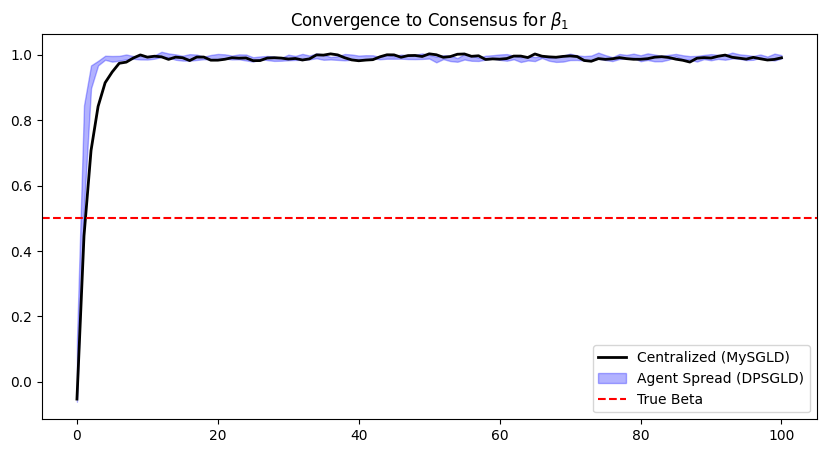

In [23]:
agent_means = history_all[:, :, 1, :].mean(axis=-1) # Shape: (101, 8)
central_mean = my_chain[:, 1, :].mean(axis=-1)     # Shape: (101,)

plt.figure(figsize=(10, 5))
plt.plot(central_mean, color='black', label='Centralized (MySGLD)', linewidth=2)

# Shade the area between the best and worst performing agent
plt.fill_between(
    range(101), 
    agent_means.min(axis=1), 
    agent_means.max(axis=1), 
    alpha=0.3, color='blue', label='Agent Spread (DPSGLD)'
)
plt.axhline(y=0.5, color='red', linestyle='--', label='True Beta')
plt.legend()
plt.title("Convergence to Consensus for $\\beta_1$")
plt.show()